In [1]:
!git clone https://github.com/Festuskipkoech/opensearch-models
!pip install -r opensearch-models/requirements.txt


Cloning into 'opensearch-models'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 24 (delta 2), reused 24 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 321.49 KiB | 13.98 MiB/s, done.
Resolving deltas: 100% (2/2), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [2]:
ls -la


total 20
drwxr-xr-x 1 root root 4096 Jul 26 00:03 ./
drwxr-xr-x 1 root root 4096 Jul 26 00:00 ../
drwxr-xr-x 4 root root 4096 Jun  4 13:39 .config/
drwxr-xr-x 6 root root 4096 Jul 26 00:03 opensearch-models/
drwxr-xr-x 1 root root 4096 Jun  4 13:39 sample_data/


# 02 — Fine-Tune the Intent Classifier

Fine-tunes `distilbert-base-uncased` for intent classification using SetFit.

SetFit works in two phases automatically:
1. Contrastive fine-tuning of the sentence transformer body on labelled pairs
2. Fitting a LogisticRegression classification head on the labelled examples

**Input:**  `data/processed/train.csv` and `data/processed/val.csv`  
**Output:** `models/classifier/` — full weight directory ready to copy to opensearch

**Gate:** all per-class F1 must exceed 0.85 on the val set before export.
If any class fails, add examples for that class, rerun notebook 01, then rerun this notebook.


## 1. Imports and configuration


In [26]:
import pandas as pd
import numpy as np
from pathlib import Path
from datasets import Dataset
from setfit import SetFitModel, Trainer, TrainingArguments
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROC_DIR = Path('opensearch-models/data/processed')
MODEL_DIR = Path('opensearch-models/models/classifier')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SENTENCE_TRANSFORMER = 'distilbert-base-uncased'
INTENT_CLASSES  = ['news', 'factual', 'code', 'research', 'commercial', 'general']
VAL_F1_THRESHOLD = 0.85
RANDOM_SEED = 42

print('SetFit training notebook ready.')
print(f'Sentence transformer : {SENTENCE_TRANSFORMER}')
print(f'Intent classes : {INTENT_CLASSES}')
print(f'Val F1 threshold : {VAL_F1_THRESHOLD}')
print(f'Output directory : {MODEL_DIR}')


SetFit training notebook ready.
Sentence transformer : distilbert-base-uncased
Intent classes : ['news', 'factual', 'code', 'research', 'commercial', 'general']
Val F1 threshold : 0.85
Output directory : opensearch-models/models/classifier


## 2. Load train and val splits


In [27]:
train_df = pd.read_csv(PROC_DIR / 'train.csv')
val_df = pd.read_csv(PROC_DIR / 'val.csv')
print('head', val_df.head())

print(f'Train examples : {len(train_df)}')
print(f'Val examples   : {len(val_df)}')
print()
print('Train class distribution:')
print(train_df['intent'].value_counts().reindex(INTENT_CLASSES).to_string())
print()
print('Val class distribution:')
print(val_df['intent'].value_counts().reindex(INTENT_CLASSES).to_string())


head                               query    intent
0                overview of autoML  research
1  overview of BGP routing protocol  research
2       overview of flash attention  research
3           tips for writing a blog   general
4   how does Redis persistence work  research
Train examples : 1014
Val examples   : 127

Train class distribution:
intent
news          164
factual       161
code          184
research      177
commercial    161
general       167

Val class distribution:
intent
news          21
factual       20
code          23
research      22
commercial    20
general       21


## 3. Label reference

SetFit handles encoding internally when `labels=` is passed at model init.
We keep a reference map here for readability only — no manual integer encoding needed.


In [28]:
label_map = {i: cls for i, cls in enumerate(INTENT_CLASSES)}
print('Label order passed to SetFit:')
for idx, cls in label_map.items():
    print(f'  {idx} -> {cls}')


Label order passed to SetFit:
  0 -> news
  1 -> factual
  2 -> code
  3 -> research
  4 -> commercial
  5 -> general


## 4. Build HuggingFace datasets


In [29]:
train_dataset = Dataset.from_dict({
    'text': train_df['query'].tolist(),
    'label': train_df['intent'].tolist(),
})

val_dataset = Dataset.from_dict({
    'text': val_df['query'].tolist(),
    'label': val_df['intent'].tolist(),
})

print(f'train_dataset: {train_dataset}')
print(f'val_dataset:   {val_dataset}')


train_dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 1014
})
val_dataset:   Dataset({
    features: ['text', 'label'],
    num_rows: 127
})


## 5. Initialise the SetFit model

SetFit wraps the sentence transformer body and classification head together.
We pass the label list so the model knows class names at inference time.
SetFit will handle all integer encoding internally, consistently.


In [30]:
model = SetFitModel.from_pretrained(
    SENTENCE_TRANSFORMER,
    labels=INTENT_CLASSES,
)

print('Model loaded.')
print(f'Body   : {SENTENCE_TRANSFORMER}')
print(f'Labels : {model.labels}')


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


Model loaded.
Body   : distilbert-base-uncased
Labels : ['news', 'factual', 'code', 'research', 'commercial', 'general']


## 6. Configure training arguments

These are the baseline hyperparameters from TRAINING.md.
Only tune if val F1 falls below threshold — see section 9 for tuning guidance.


In [31]:
args = TrainingArguments(
    batch_size=16,
    num_epochs=3,
    num_iterations=20,
    seed=RANDOM_SEED,
)

print('Training arguments:')
print(f'batch_size : {args.batch_size}')
print(f'num_epochs : {args.num_epochs} (contrastive learning phase)')
print(f'num_iterations : {args.num_iterations} (contrastive pairs per example)')
print(f'seed : {args.seed}')


Training arguments:
batch_size : (16, 16)
num_epochs : (3, 3) (contrastive learning phase)
num_iterations : 20 (contrastive pairs per example)
seed : 42


## 7. Train

SetFit runs two phases back to back:
- Phase A: contrastive fine-tuning of the sentence transformer on sampled pairs
- Phase B: fitting the LogisticRegression head on the full training set embeddings

Expected wall time on CPU: 5 to 20 minutes depending on dataset size and hardware.


In [32]:
import time

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    metric='accuracy',
)

print('Starting training...')
t0 = time.time()
trainer.train()
elapsed = time.time() - t0

print(f'Training complete in {elapsed:.0f}s ({elapsed/60:.1f} min)')


Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Starting training...


***** Running training *****
  Num unique pairs = 40560
  Batch size = 16
  Num epochs = 3


Step,Training Loss
1,0.171500
50,0.243500
100,0.215200
150,0.166200
200,0.131600
250,0.089700
300,0.056800
350,0.038400
400,0.021100
450,0.011600


Training complete in 514s (8.6 min)


## 8. Evaluate on the val set

This is the gate. All per-class F1 must exceed 0.85.
If any class fails, do not export. See section 9 for next steps.


In [33]:
val_texts  = val_df['query'].tolist()
val_labels = val_df['intent'].tolist()

predictions = list(model.predict(val_texts))

print(f'first 5 predictions : {predictions[:5]}')
print(f'first 5 val_labels  : {val_labels[:5]}')

overall_accuracy = accuracy_score(val_labels, predictions)
print(f'Val accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)')


first 5 predictions : [np.str_('research'), np.str_('research'), np.str_('research'), np.str_('general'), np.str_('research')]
first 5 val_labels  : ['research', 'research', 'research', 'general', 'research']
Val accuracy: 0.9921 (99.21%)


In [34]:
report = classification_report(
    val_labels,
    predictions,
    labels=INTENT_CLASSES,
    output_dict=True,
)

report_df = pd.DataFrame(report).T.loc[INTENT_CLASSES, ['precision', 'recall', 'f1-score', 'support']]
report_df = report_df.round(4)
print('Per-class metrics on val set:')
print(report_df.to_string())


Per-class metrics on val set:
            precision  recall  f1-score  support
news           0.9545    1.00    0.9767     21.0
factual        1.0000    1.00    1.0000     20.0
code           1.0000    1.00    1.0000     23.0
research       1.0000    1.00    1.0000     22.0
commercial     1.0000    0.95    0.9744     20.0
general        1.0000    1.00    1.0000     21.0


In [35]:
print('Val set F1 gate:')
gate_passed = True
for cls in INTENT_CLASSES:
    f1 = report[cls]['f1-score']
    status = 'PASS' if f1 >= VAL_F1_THRESHOLD else 'FAIL'
    print(f'{status}  {cls:<12}  F1={f1:.4f}  (threshold={VAL_F1_THRESHOLD})')
    if f1 < VAL_F1_THRESHOLD:
        gate_passed = False

print()
if gate_passed:
    print('All classes pass the F1 threshold. Proceed to export.')
else:
    print('One or more classes failed. See section 9 before exporting.')


Val set F1 gate:
PASS  news          F1=0.9767  (threshold=0.85)
PASS  factual       F1=1.0000  (threshold=0.85)
PASS  code          F1=1.0000  (threshold=0.85)
PASS  research      F1=1.0000  (threshold=0.85)
PASS  commercial    F1=0.9744  (threshold=0.85)
PASS  general       F1=1.0000  (threshold=0.85)

All classes pass the F1 threshold. Proceed to export.


## 8b. Confusion matrix


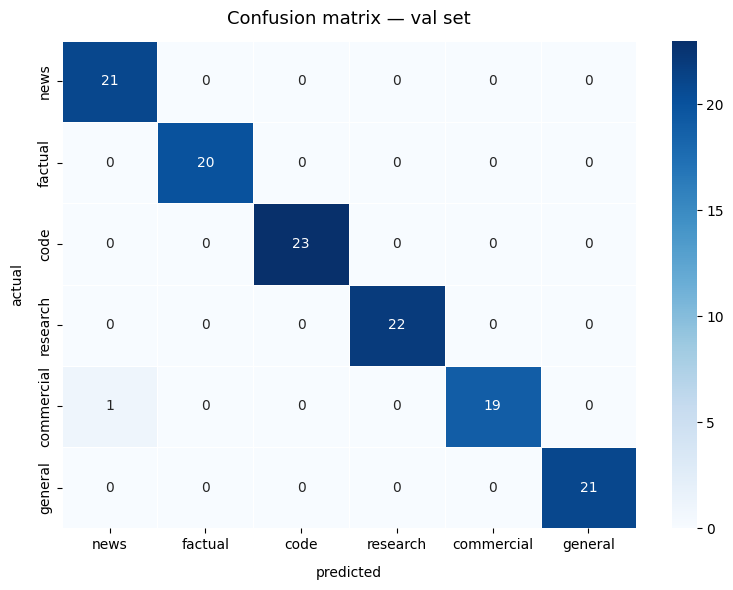

Diagonal = correct. Off-diagonal = misclassified.
Any row with significant off-diagonal values indicates a weak class.


In [36]:
cm = confusion_matrix(val_labels, predictions, labels=INTENT_CLASSES)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=INTENT_CLASSES,
    yticklabels=INTENT_CLASSES,
    linewidths=0.5,
    ax=ax,
)
ax.set_xlabel('predicted', labelpad=10)
ax.set_ylabel('actual', labelpad=10)
ax.set_title('Confusion matrix — val set', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print('Diagonal = correct. Off-diagonal = misclassified.')
print('Any row with significant off-diagonal values indicates a weak class.')


## 8c. Inspect misclassified examples

Look at what the model got wrong. This reveals labelling ambiguity
or insufficient examples in specific areas of a class.


In [37]:
val_df_copy = val_df.copy()
val_df_copy['predicted'] = predictions
misclassified = val_df_copy[val_df_copy['intent'] != val_df_copy['predicted']]

print(f'Misclassified examples: {len(misclassified)} of {len(val_df)} ({len(misclassified)/len(val_df)*100:.1f}%)')
print()

if len(misclassified) > 0:
    for _, row in misclassified.iterrows():
        print(f'  query     : {row["query"]}')
        print(f'  actual    : {row["intent"]}')
        print(f'  predicted : {row["predicted"]}')
        print()


Misclassified examples: 1 of 127 (0.8%)

  query     : iphone versus samsung
  actual    : commercial
  predicted : news



## 9. Hyperparameter tuning (run only if val F1 gate failed)

Work through these steps in order. Stop as soon as the gate passes.

**Step 1 — More contrastive pairs**  
Change `num_iterations=40` in section 6 and retrain.

**Step 2 — More epochs**  
Change `num_epochs=3` in section 6 and retrain.

**Step 3 — Different classifier head**  
Change to `SGDClassifier` as shown below.

**Step 4 — More data for the failing class**  
Add examples to `data/raw/queries.csv`, rerun notebook 01 to regenerate splits,
then rerun this notebook from the top.

**Step 5 — Stronger base model (last resort)**  
Change `SENTENCE_TRANSFORMER` in section 1 to
`sentence-transformers/all-mpnet-base-v2` and retrain.


In [ ]:
# Run this cell only if you want to switch to SGDClassifier (step 3 above)

from sklearn.linear_model import SGDClassifier

model_sgd = SetFitModel.from_pretrained(
    SENTENCE_TRANSFORMER,
    labels=INTENT_CLASSES,
)

# Uncomment and run the block below to train with SGD head
# trainer_sgd = Trainer(
#     model=model_sgd,
#     args=args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     metric='accuracy',
# )
# trainer_sgd.train()
# model = model_sgd  # replace model reference for export below

print('SGD model initialised but not yet trained.')
print('Uncomment the trainer block above to use it.')


## 10. Quick inference check

Manual spot-check before saving. Verify the model behaves as expected
on a handful of clear examples from each class.


In [38]:
spot_check = [
    ('kenya election results today', 'news'),
    ('champions league final result', 'news'),
    ('capital of france', 'factual'),
    ('when was redis created', 'factual'),
    ('how to handle goroutine panic in go', 'code'),
    ('implement LRU cache golang', 'code'),
    ('cap theorem distributed systems', 'research'),
    ('how does LORA fine-tuning work', 'research'),
    ('best laptop under 1000', 'commercial'),
    ('top cloud providers africa region', 'commercial'),
    ('how to make ugali', 'general'),
    ('how does ai work', 'research'),
    ('tips for staying productive working from home', 'general'),
]

queries  = [q for q, _ in spot_check]
expected = [e for _, e in spot_check]
got = list(model.predict(queries))

print('Spot-check predictions:')
print(f'{"query":<50}  {"expected":<12}  {"got":<12}  match')
print('-' * 95)
for q, exp, pred in zip(queries, expected, got):
    match = 'OK' if exp == pred else 'WRONG'
    print(f'{q:<50}  {exp:<12}  {pred:<12}  {match}')


Spot-check predictions:
query                                               expected      got           match
-----------------------------------------------------------------------------------------------
kenya election results today                        news          news          OK
champions league final result                       news          news          OK
capital of france                                   factual       factual       OK
when was redis created                              factual       factual       OK
how to handle goroutine panic in go                 code          code          OK
implement LRU cache golang                          code          code          OK
cap theorem distributed systems                     research      research      OK
how does LORA fine-tuning work                      research      research      OK
best laptop under 1000                              commercial    commercial    OK
top cloud providers africa region              

## 11. Save the model

Only run this cell if the val F1 gate in section 8 passed for all classes.

This saves the complete model directory:
- `config.json`
- `tokenizer_config.json` / `tokenizer.json` / `vocab.txt`
- `model.safetensors` (or `pytorch_model.bin`)
- `model_head.pkl` (the LogisticRegression head)

After saving, copy the directory to opensearch per `docs/EXPORT.md`.


In [39]:
if not gate_passed:
    raise RuntimeError(
        'Val F1 gate did not pass. Fix failing classes before saving. '
        'See section 9 for tuning steps.'
    )

model.save_pretrained(str(MODEL_DIR))

saved_files = sorted(MODEL_DIR.iterdir())
print(f'Model saved to {MODEL_DIR}/')
print()
for f in saved_files:
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<40}  {size_kb:>8.1f} KB')


Model saved to opensearch-models/models/classifier/

  1_Pooling                                      4.0 KB
  README.md                                     13.8 KB
  config.json                                    0.5 KB
  config_sentence_transformers.json              0.3 KB
  config_setfit.json                             0.1 KB
  model.safetensors                         259240.8 KB
  model_head.pkl                                37.1 KB
  modules.json                                   0.3 KB
  sentence_bert_config.json                      0.2 KB
  special_tokens_map.json                        0.1 KB
  tokenizer.json                               695.0 KB
  tokenizer_config.json                          1.2 KB
  vocab.txt                                    226.1 KB


In [40]:
import shutil
shutil.make_archive('classifier', 'zip', 'opensearch-models/models/classifier')

'/content/classifier.zip'

In [41]:
from google.colab import files
files.download('classifier.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Summary

Print a clean summary to record before closing the notebook.


In [42]:
print('=' * 60)
print('TRAINING SUMMARY')
print('=' * 60)
print(f'Base model : {SENTENCE_TRANSFORMER}')
print(f'Training examples: {len(train_df)}')
print(f'Val examples : {len(val_df)}')
print(f'Training time : {elapsed:.0f}s')
print(f'Val accuracy : {overall_accuracy*100:.2f}%')
print()
print('Per-class F1 (val):')
for cls in INTENT_CLASSES:
    f1 = report[cls]['f1-score']
    bar = '#' * int(f1 * 20)
    print(f' {cls:<12} {f1:.4f}  {bar}')
print()
print(f'Weights saved to : {MODEL_DIR}')
print()
print('Next step: run 03_evaluate_classifier.ipynb on the held-out test set.')
print('=' * 60)


TRAINING SUMMARY
Base model : distilbert-base-uncased
Training examples: 1014
Val examples : 127
Training time : 514s
Val accuracy : 99.21%

Per-class F1 (val):
 news         0.9767  ###################
 factual      1.0000  ####################
 code         1.0000  ####################
 research     1.0000  ####################
 commercial   0.9744  ###################
 general      1.0000  ####################

Weights saved to : opensearch-models/models/classifier

Next step: run 03_evaluate_classifier.ipynb on the held-out test set.
